# Project C4 - Blood Cell Type Prediction (BloodMNIST)

Comparison of four architectures for classifying 8 types of peripheral blood cells from microscopy images (BloodMNIST):

1. **Baseline CNN**
2. **CNN + Squeeze-and-Excitation** 
3. **Patch-based decision fusion** 
4. **Spiking Neural Network (SNN)** 
**Notebook structure:**
1. Setup
2. Exploratory Data Analysis 
3. Three CNN architectures (TensorFlow) - baseline, SE-CNN, patch fusion
4. SE-CNN retry with tuned hyperparameters (best CNN result)
5. Spiking Neural Network (PyTorch) - 28x28 (course lab) and 64x64 (final, tuned)



## 1. Setup

In [1]:
!pip install -q medmnist #-q stay for "quiet", that means to stamp less lines code
!pip install -q medmnist snntorch
import numpy as np 
import pandas as pd 
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
import kagglehub
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
import medmnist
from medmnist import INFO
from sklearn.metrics import classification_report, confusion_matrix
import json
import time 
from contextlib import contextmanager #a tool to build the "timer" helper
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import snntorch as snn
from snntorch import surrogate
from snntorch import functional as SF
import tqdm
import random
SEED = 10
tf.keras.utils.set_random_seed(SEED)
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 1.3 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.6/133.6 kB 1.4 MB/s eta 0:00:00a 0:00:01
/kaggle/input/datasets/nikolicjelena/bloodcell-trained-models/timing_log.txt
/kaggle/input/datasets/nikolicjelena/bloodcell-trained-models/live_demo.png
/kaggle/input/datasets/nikolicjelena/bloodcell-trained-models/model_comparison.png
/kaggle/input/datasets/nikolicjelena/bloodcell-trained-models/reports/snn_history.json
/kaggle/input/datasets/nikolicjelena/bloodcell-trained-models/reports/results_summary.json
/kaggle/input/datasets/nikolicjelena/bloodcell-trained-models/reports/center_crop_report.txt
/kaggle/input/datasets/nikolicjelena/bloodcell-trained-models/reports/baseline_cnn_history.json
/kaggle/input/datasets/nikolicjelena/bloodcell-trained-models/reports/se_cnn_v2_report.txt
/kaggle/input/datasets/nikolicjelena/bloodcell-trained-models/reports/snn64_report.txt
/kaggle/input/datasets/nikolicjelena/bloo

## 2. Exploratory Data Analysis (EDA)

Produces class distribution plots, a grid of example images per class, pixel statistics, and a text summary saved to `/kaggle/working/eda class imbalance ratio ~2.74x (moderate, not severe - no class weighting needed); pixel value range is [8, 255], never fully black, consistent with the pink/cream microscopy staining background.


In [ ]:
# 0. Path setup: Kaggle vs local (same logic as the training script)

ON_KAGGLE = os.environ.get("KAGGLE_KERNEL_RUN_TYPE") is not None

if ON_KAGGLE:
    DATA_DIR = "/kaggle/temp/medmnist_data" # syntetic data
    OUTPUT_DIR = "/kaggle/working/eda" #where we save the output
else:
    DATA_DIR = "./medmnist_data"
    OUTPUT_DIR = "./output/eda"

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)


# 1. Load data 

DATA_FLAG = "bloodmnist"
IMAGE_SIZE = 64  

info = INFO[DATA_FLAG] #metadata
n_classes = len(info["label"]) #8 classes 
class_names = list(info["label"].values())

DataClass = getattr(medmnist, info["python_class"])

train_dataset = DataClass(split="train", download=True, size=IMAGE_SIZE, root=DATA_DIR) 
val_dataset   = DataClass(split="val",   download=True, size=IMAGE_SIZE, root=DATA_DIR)
test_dataset  = DataClass(split="test",  download=True, size=IMAGE_SIZE, root=DATA_DIR)

X_train, y_train = train_dataset.imgs, train_dataset.labels[:, 0]
X_val,   y_val   = val_dataset.imgs,   val_dataset.labels[:, 0]
X_test,  y_test  = test_dataset.imgs,  test_dataset.labels[:,0]

print(f"Dataset: {DATA_FLAG}, resolution {IMAGE_SIZE}x{IMAGE_SIZE}")
print(f"Classes ({n_classes}): {class_names}")
print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")
print(f"Image dtype: {X_train.dtype}, value range: [{X_train.min()}, {X_train.max()}]")


# 2. Class distribution per split


def class_counts(labels, n_classes):
    return np.bincount(labels, minlength=n_classes)
counts_train = class_counts(y_train, n_classes)
counts_val   = class_counts(y_val, n_classes)
counts_test  = class_counts(y_test, n_classes)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(n_classes)
width = 0.25
ax.bar(x - width, counts_train, width, label="train")
ax.bar(x,          counts_val,   width, label="val")
ax.bar(x + width,  counts_test,  width, label="test")
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=30, ha="right")
ax.set_ylabel("Number of images")
ax.set_title("Class distribution per split - BloodMNIST")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "class_distribution.png"), dpi=150)
plt.close()

# Ratio between the most frequent and least frequent class 

imbalance_ratio = counts_train.max() / counts_train.min()



# 3. Grid of visual examples, one row per class

n_examples_per_class = 6
fig, axes = plt.subplots(n_classes, n_examples_per_class, figsize=(n_examples_per_class * 1.6, n_classes * 1.6))

for class_idx in range(n_classes):
    class_images = X_train[y_train == class_idx]
    chosen = class_images[:n_examples_per_class] #slicing
    for col in range(n_examples_per_class):
        ax = axes[class_idx, col]
        if col < len(chosen):
            ax.imshow(chosen[col])
        ax.axis("off")
        if col == 0:
            ax.set_ylabel(class_names[class_idx], rotation=0, ha="right", va="center", fontsize=9)
            ax.axis("on")
            ax.set_xticks([])
            ax.set_yticks([])
            for spine in ax.spines.values():
                spine.set_visible(False)

plt.suptitle("Examples per class - BloodMNIST (training set)", y=1.0)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "sample_grid.png"), dpi=150, bbox_inches="tight")
plt.close()


# 4. Pixel statistics: global RGB histograms + mean brightness per class



fig, axes = plt.subplots(1, 2, figsize=(14, 5))

rng = np.random.default_rng(42)  # random number generator, fixed seed so results repeat every run
sample_idx = rng.choice(len(X_train), size=min(2000, len(X_train)), replace=False)  # pick 2000 random image positions, no repeats
sample_imgs = X_train[sample_idx].astype("float32")  # get those 2000 images, convert to decimal numbers

colors = ["red", "green", "blue"]  # the three color channels we want to check
for c, color in enumerate(colors):  # c = 0,1,2 and color = "red","green","blue", one pair per loop
    axes[0].hist(sample_imgs[:, :, :, c].ravel(), bins=50, alpha=0.5, color=color, label=f"{color} channel")

axes[0].set_title("Pixel value distribution per RGB channel")
axes[0].set_xlabel("Pixel value (0-255)")
axes[0].set_ylabel("Frequency")
axes[0].legend()

mean_brightness_per_class = [
    X_train[y_train == c].astype("float32").mean() for c in range(n_classes)
]  # one number per class: average brightness of all its images

axes[1].bar(class_names, mean_brightness_per_class, color="steelblue")
axes[1].set_title("Mean brightness per class")
axes[1].set_ylabel("Mean pixel value (0-255)")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "pixel_stats.png"), dpi=150)
plt.close()

channel_mean = X_train.astype("float32").mean(axis=(0, 1, 2)) / 255.0  # average of R, G, B across the whole dataset, scaled to 0-1
channel_std  = X_train.astype("float32").std(axis=(0, 1, 2)) / 255.0   # how spread out R, G, B values are, scaled to 0-1

# Mean and standard deviation per channel over the whole training set: these
# are the numbers you'd need if you later decide to normalize per channel
# (standardization) instead of a simple /255
channel_mean = X_train.astype("float32").mean(axis=(0, 1, 2)) / 255.0
channel_std  = X_train.astype("float32").std(axis=(0, 1, 2)) / 255.0


# 5. summary

summary_path = os.path.join(OUTPUT_DIR, "eda_summary.txt")
with open(summary_path, "w") as f:
    f.write("=== EDA summary - BloodMNIST ===\n\n")
    f.write(f"Resolution used: {IMAGE_SIZE}x{IMAGE_SIZE}x3\n")
    f.write(f"Number of classes: {n_classes}\n")
    f.write(f"Split sizes - train: {len(X_train)}, val: {len(X_val)}, test: {len(X_test)}\n\n")

    f.write("Image counts per class (train / val / test):\n")
    for i, name in enumerate(class_names):
        f.write(f"  {name:25s}: {counts_train[i]:5d} / {counts_val[i]:4d} / {counts_test[i]:4d}\n")
    f.write(f"\nImbalance ratio (max class / min class, train): {imbalance_ratio:.2f}\n\n")

    f.write(f"Per-channel RGB mean (normalized 0-1): R={channel_mean[0]:.3f}, "
            f"G={channel_mean[1]:.3f}, B={channel_mean[2]:.3f}\n")
    f.write(f"Per-channel RGB std (normalized 0-1): R={channel_std[0]:.3f}, "
            f"G={channel_std[1]:.3f}, B={channel_std[2]:.3f}\n")

print(f"\nEDA complete. Files saved to: {OUTPUT_DIR}")
print(f"  - class_distribution.png")
print(f"  - sample_grid.png")
print(f"  - pixel_stats.png")
print(f"  - eda_summary.txt")
print(f"\nClass imbalance ratio (train): {imbalance_ratio:.2f}x")


In [ ]:
from IPython.display import Image, display
display(Image("/kaggle/working/eda/sample_grid.png"))


## 3. Three CNN architectures (TensorFlow)

The baseline CNN, the CNN + Squeeze-and-Excitation, and the patch-based fusion CNN, all in the same run.

**Results (first attempt):** Baseline 95.59%, SE-CNN 89.80% (unstable, superseded - see section 4), Patch fusion 96.20%.

In [ ]:

# 0. Path setup: Kaggle vs local

ON_KAGGLE = os.environ.get("KAGGLE_KERNEL_RUN_TYPE") is not None
#  check if a Kaggle-only variable exists -> True if we are on Kaggle, False otherwise

if ON_KAGGLE:                                  
    DATA_DIR = "/kaggle/temp/medmnist_data"    
    OUTPUT_DIR = "/kaggle/working"             
else:                                          
    DATA_DIR = "./medmnist_data"              
    OUTPUT_DIR = "./output"                   
MODEL_DIR = os.path.join(OUTPUT_DIR, "models")     
REPORTS_DIR = os.path.join(OUTPUT_DIR, "reports")  

for d in (DATA_DIR, MODEL_DIR, REPORTS_DIR):   
    os.makedirs(d, exist_ok=True)              

print(f"Kaggle environment detected: {ON_KAGGLE}")  
print(f"Raw data (scratch):     {DATA_DIR}")        
print(f"Persistent output:      {OUTPUT_DIR}")       



@contextmanager   
def timer(phase_name, log_path=os.path.join(OUTPUT_DIR, "timing_log.txt")):
    start = time.time()                    
    print(f"\n>>> [{phase_name}] starting...") 
    yield                                   
    elapsed = time.time() - start           
    minutes, seconds = divmod(elapsed, 60)  
    msg = f"[{phase_name}] completed in {int(minutes)}m {seconds:.1f}s"  
    print(f">>> {msg}")                     
    with open(log_path, "a") as f:          
        f.write(msg + "\n")                 


# 1. Configuration and data loading

DATA_FLAG = "bloodmnist"  
IMAGE_SIZE = 64           
BATCH_SIZE = 64            
EPOCHS = 25                 

info = INFO[DATA_FLAG]                          
n_classes = len(info["label"])                  
class_names = list(info["label"].values())      
print(f"Classes ({n_classes}): {info['label']}") 

DataClass = getattr(medmnist, info["python_class"])


with timer("Data download/loading"):   
    train_dataset = DataClass(split="train", download=True, size=IMAGE_SIZE, root=DATA_DIR)
    val_dataset   = DataClass(split="val",   download=True, size=IMAGE_SIZE, root=DATA_DIR)
    test_dataset  = DataClass(split="test",  download=True, size=IMAGE_SIZE, root=DATA_DIR)

    def to_numpy(dataset):
        imgs = dataset.imgs.astype("float32") / 255.0 #  get images, convert to decimal numbers, scale from 0-255 down to 0-1
        labels = dataset.labels.astype("int32").squeeze()
        return imgs, labels   # give back both results together

    X_train, y_train = to_numpy(train_dataset)   
    X_val,   y_val   = to_numpy(val_dataset)    
    X_test,  y_test  = to_numpy(test_dataset)    

print("Train shape:", X_train.shape, y_train.shape)   
print("Val shape:  ", X_val.shape,   y_val.shape)      
print("Test shape: ", X_test.shape,  y_test.shape)     

input_shape = X_train.shape[1:]
# ^ take the shape (N, 64, 64, 3) and drop the first number (N = image count) -> (64, 64, 3)


def make_data_augmentation():
    return models.Sequential([              
        layers.RandomFlip("horizontal"),    
        layers.RandomRotation(0.1),         
        layers.RandomZoom(0.1),             
    ])


def callbacks_factory(model_name):
    bestm_path = os.path.join(MODEL_DIR, f"{model_name}_best.keras")
    return [
        tf.keras.callbacks.EarlyStopping(patience=6, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=3),
        tf.keras.callbacks.ModelCheckpoint(bestm_path, save_best_only=True, monitor="val_accuracy"),
    
    ]



# 2. Squeeze-and-Excitation block (channel attention)

def se_block(x, reduction=8):
    channels = x.shape[-1]                       
    s = layers.GlobalAveragePooling2D()(x)       
    s = layers.Dense(channels // reduction, activation="relu")(s)
    s = layers.Dense(channels, activation="sigmoid")(s)
    s = layers.Reshape((1, 1, channels))(s)    
    return layers.Multiply()([x, s])             # rescale x, channel by channel
# basically, this is the attention block that checks the channels and decides which ones are more important

# 3. Architectures

def conv_block(x, filters):
    x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)     
    x = layers.MaxPooling2D()(x)           
    return x                             

def build_baseline_cnn(input_shape, n_classes, augment=True):
    inputs = layers.Input(shape=input_shape)       
    x = make_data_augmentation()(inputs) if augment else inputs #  if augment is True, pass inputs through augmentation; otherwise skip it

    x = conv_block(x, 32)    
    x = conv_block(x, 64)    
    x = conv_block(x, 128)  

    x = layers.GlobalAveragePooling2D()(x)   
    x = layers.Dense(128, activation="relu")(x)  
    x = layers.Dropout(0.4)(x)             
    outputs = layers.Dense(n_classes, activation="softmax")(x)
    return models.Model(inputs, outputs, name="baseline_cnn")



def build_se_cnn(input_shape, n_classes, augment=True):
    inputs = layers.Input(shape=input_shape)        
    x = make_data_augmentation()(inputs) if augment else inputs  
    for filters in [32, 64, 128]:    
        x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)  
        x = layers.BatchNormalization()(x)  
        x = se_block(x)                      # apply channel attention here
        x = layers.MaxPooling2D()(x)        

    x = layers.GlobalAveragePooling2D()(x) 
    x = layers.Dense(128, activation="relu")(x) 
    x = layers.Dropout(0.4)(x)              
    outputs = layers.Dense(n_classes, activation="softmax")(x) 
    return models.Model(inputs, outputs, name="se_cnn")  


def compile_model(model, lr=1e-3):
  # lr = learning rate, default 0.001
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
        
    )
    return model   


def save_history(history, name):
    # history = the object returned by model.fit(); name = text label for the file name
    hist_path = os.path.join(REPORTS_DIR, f"{name}_history.json")   
    with open(hist_path, "w") as f:   
        json.dump({k: [float(v) for v in vals] for k, vals in history.history.items()}, f, indent=2)
        #  convert the history data to plain numbers and save it as readable json text


# 4. Training: baseline and SE-CNN

with timer("Training baseline CNN"):    # time this whole block as one phase
    baseline_model = compile_model(build_baseline_cnn(input_shape, n_classes))
    baseline_model.summary()            
    history_baseline = baseline_model.fit(
        X_train, y_train,                    
        validation_data=(X_val, y_val),      
        batch_size=BATCH_SIZE, epochs=EPOCHS,  
        callbacks=callbacks_factory("baseline_cnn"), 
    )

    save_history(history_baseline, "baseline_cnn")  
    baseline_model.save(os.path.join(MODEL_DIR, "baseline_cnn_final.keras"))
    

with timer("Training CNN + Squeeze-and-Excitation (first attempt, default hyperparameters)"):
    # by an improved version (se_cnn_v2) with better hyperparameters.
    se_model = compile_model(build_se_cnn(input_shape, n_classes))
    se_model.summary()                   
    history_se = se_model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        batch_size=BATCH_SIZE, epochs=EPOCHS,
        callbacks=callbacks_factory("se_cnn"),
    )
    save_history(history_se, "se_cnn")   
    se_model.save(os.path.join(MODEL_DIR, "se_cnn_final.keras"))   


# 5. Patch-based decision fusion


PATCH_SIZE = IMAGE_SIZE // 2 

def extract_patches(images):
   
    h, w = images.shape[1], images.shape[2]    
    half_h, half_w = h // 2, w // 2            

    patches = []                
    for img in images:          # loop over every image in the batch, one at a time
        patches.append(img[0:half_h, 0:half_w, :])       # top-left quarter
        patches.append(img[0:half_h, half_w:w, :])       # top-right quarter
        patches.append(img[half_h:h, 0:half_w, :])       # bottom-left quarter
        patches.append(img[half_h:h, half_w:w, :])       # bottom-right quarter
    return np.stack(patches, axis=0)
    


def expand_labels_for_patches(labels, n_patches=4):
    return np.repeat(labels, n_patches)
    


with timer("Preparing patches for decision fusion"):
    X_train_patches = extract_patches(X_train)             
    y_train_patches = expand_labels_for_patches(y_train)    

    X_val_patches = extract_patches(X_val)                 
    y_val_patches = expand_labels_for_patches(y_val)        

    print("Train patches shape:", X_train_patches.shape)   

patch_input_shape = (PATCH_SIZE, PATCH_SIZE, 3)   

with timer("Training CNN on patches (decision fusion)"):
    patch_model = compile_model(build_baseline_cnn(patch_input_shape, n_classes))
    patch_model.summary()                
    history_patch = patch_model.fit(
        X_train_patches, y_train_patches,         
        validation_data=(X_val_patches, y_val_patches),
        batch_size=BATCH_SIZE, epochs=EPOCHS,
        callbacks=callbacks_factory("patch_cnn"),
    )
   
    save_history(history_patch, "patch_cnn")     
    patch_model.save(os.path.join(MODEL_DIR, "patch_cnn_final.keras"))  


def predict_with_patch_fusion(model, images):
    n = images.shape[0]                        
    patches = extract_patches(images)         
    probs = model.predict(patches, verbose=0)  
    probs = probs.reshape(n, 4, n_classes)    
    avg_probs = probs.mean(axis=1)             
    return np.argmax(avg_probs, axis=1)
   

# 6. Final evaluation and comparison on the test set

with timer("Final evaluation on the test set"):
   
    baseline_test_loss, baseline_test_acc = baseline_model.evaluate(X_test, y_test, verbose=0)
    y_pred_baseline = np.argmax(baseline_model.predict(X_test, verbose=0), axis=1)


    # --- SE-CNN (first attempt) ---
    se_test_loss, se_test_acc = se_model.evaluate(X_test, y_test, verbose=0)
    y_pred_se = np.argmax(se_model.predict(X_test, verbose=0), axis=1)
   

    # --- Patch fusion ---
    y_pred_patch = predict_with_patch_fusion(patch_model, X_test)
    patch_test_acc = np.mean(y_pred_patch == y_test)
  

    results = {
        "Baseline CNN": baseline_test_acc,                      
        "CNN + SE (attention, first attempt)": se_test_acc,  
        "Patch-based fusion": patch_test_acc,                   
    }

    print("\n--- Test set accuracy summary ---")
    for name, acc in results.items():          
        print(f"{name:35s}: {acc:.4f}")        

    
    report_txt_path = os.path.join(REPORTS_DIR, "classification_reports.txt")   
    with open(report_txt_path, "w") as f:      
        for name, y_pred in [                 
            ("Baseline CNN", y_pred_baseline),
            ("CNN + SE (attention, first attempt)", y_pred_se),
            ("Patch-based fusion", y_pred_patch),
        ]:
            report_str = classification_report(y_test, y_pred, target_names=class_names)

            cm = confusion_matrix(y_test, y_pred)
    

            print(f"\n=== Classification report: {name} ===")  
            print(report_str)                                    

            f.write(f"=== Classification report: {name} ===\n")  
            f.write(report_str + "\n")                            
            f.write("Confusion matrix:\n")                       
            f.write(np.array2string(cm) + "\n\n")
            

    # Accuracy summary also as JSON, handy for the final report
    with open(os.path.join(REPORTS_DIR, "results_summary.json"), "w") as f:  # open json file
        json.dump({k: float(v) for k, v in results.items()}, f, indent=2)
        #  save the results dictionary as json, converting numbers to plain floats first

    print(f"\nText reports saved to: {report_txt_path}") 
    


# 7. Comparison plot (accuracy per model)

plt.figure(figsize=(7, 5))              
names = list(results.keys())           
values = list(results.values())         
colors = ["#4C72B0", "#55A868", "#C44E52"] 
bars = plt.bar(names, values, color=colors)  
plt.ylabel("Test Accuracy")             
plt.ylim(0, 1)                          
plt.title("Architecture comparison - bloodMNIST (C4)")   
for bar, v in zip(bars, values):        #
    plt.text(bar.get_x() + bar.get_width() / 2, v + 0.01, f"{v:.3f}",
              ha="center", fontweight="bold")
    
plt.tight_layout()                     

plot_path = os.path.join(OUTPUT_DIR, "model_comparison.png")   
plt.savefig(plot_path, dpi=150)         
plt.show()                              
print(f"\nComparison plot saved to '{plot_path}'")  

print("\n=== Summary of files saved to /kaggle/working/ ===")   
print(f"- Model weights:      {MODEL_DIR}/*.keras")             
print(f"- Training history:   {REPORTS_DIR}/*_history.json")
print(f"- Reports + matrices: {REPORTS_DIR}/classification_reports.txt")
print(f"- Accuracy summary:   {REPORTS_DIR}/results_summary.json")
print(f"- Phase timing log:   {OUTPUT_DIR}/timing_log.txt")
print(f"- Final plot:         {plot_path}")

## 4. SE-CNN retry: tuned hyperparameters

The first SE-CNN attempt trained unstably and was stopped early during an unstable phase (89.80% test accuracy).
I bring the learning rate 1e-3 to 5e-4 and raises the EarlyStopping patience (6 -> 10), giving the model more room to get past the unstable phase.

**Result: 96.76% test accuracy - the best of the three CNN architectures.** This is the model (`se_cnn_v2`) used in the final comparison and in the live demo.

In [ ]:


# 0. Path setup (identical to the main script)

ON_KAGGLE = os.environ.get("KAGGLE_KERNEL_RUN_TYPE") is not None
DATA_DIR = "/kaggle/temp/medmnist_data" if ON_KAGGLE else "./medmnist_data"
OUTPUT_DIR = "/kaggle/working" if ON_KAGGLE else "./output"
MODEL_DIR = os.path.join(OUTPUT_DIR, "models")
REPORTS_DIR = os.path.join(OUTPUT_DIR, "reports")
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(REPORTS_DIR, exist_ok=True)

@contextmanager
def timer(phase_name):
    start = time.time()
    print(f"\n>>> [{phase_name}] starting...")
    yield
    elapsed = time.time() - start
    print(f">>> [{phase_name}] completed in {int(elapsed // 60)}m {elapsed % 60:.1f}s")



# 1. Data 

DATA_FLAG = "bloodmnist"
IMAGE_SIZE = 64
BATCH_SIZE = 64

info = INFO[DATA_FLAG]
n_classes = len(info["label"])
class_names = list(info["label"].values())

DataClass = getattr(medmnist, info["python_class"])

with timer("Data loading"):
    train_dataset = DataClass(split="train", download=True, size=IMAGE_SIZE, root=DATA_DIR)
    val_dataset   = DataClass(split="val",   download=True, size=IMAGE_SIZE, root=DATA_DIR)
    test_dataset  = DataClass(split="test",  download=True, size=IMAGE_SIZE, root=DATA_DIR)

    def to_numpy(dataset):
        imgs = dataset.imgs.astype("float32") / 255.0
        labels = dataset.labels.astype("int32").squeeze()
        return imgs, labels

    X_train, y_train = to_numpy(train_dataset)
    X_val,   y_val   = to_numpy(val_dataset)
    X_test,  y_test  = to_numpy(test_dataset)

input_shape = X_train.shape[1:]



# 2. SE-CNN architecture (identical to the original)

def make_data_augmentation():
    return models.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
    ])


def se_block(x, reduction=8):
    channels = x.shape[-1]
    se = layers.GlobalAveragePooling2D()(x)
    se = layers.Dense(channels // reduction, activation="relu")(se)
    se = layers.Dense(channels, activation="sigmoid")(se)
    se = layers.Reshape((1, 1, channels))(se)
    return layers.Multiply()([x, se])


def build_se_cnn(input_shape, n_classes, augment=True):
    inputs = layers.Input(shape=input_shape)
    x = make_data_augmentation()(inputs) if augment else inputs

    for filters in [32, 64, 128]:
        x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
        x = layers.BatchNormalization()(x)
        x = se_block(x)
        x = layers.MaxPooling2D()(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(n_classes, activation="softmax")(x)
    return models.Model(inputs, outputs, name="se_cnn_v2")



# 3. Training with more conservative hyperparameters

LEARNING_RATE = 5e-4   # was 1e-3
EARLY_STOPPING_PATIENCE = 10  # was 6
EPOCHS = 35            # raised slightly to give the higher patience room to work

se_model_v2 = build_se_cnn(input_shape, n_classes)
se_model_v2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
se_model_v2.summary()

callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=EARLY_STOPPING_PATIENCE, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=4),
    tf.keras.callbacks.ModelCheckpoint(
        os.path.join(MODEL_DIR, "se_cnn_v2_best.keras"), save_best_only=True, monitor="val_accuracy"
    ),
]

with timer("Training SE-CNN v2 (reduced learning rate, increased patience)"):
    history_se_v2 = se_model_v2.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        batch_size=BATCH_SIZE, epochs=EPOCHS,
        callbacks=callbacks,
    )

se_model_v2.save(os.path.join(MODEL_DIR, "se_cnn_v2_final.keras"))
with open(os.path.join(REPORTS_DIR, "se_cnn_v2_history.json"), "w") as f:
    json.dump({k: [float(v) for v in vals] for k, vals in history_se_v2.history.items()}, f, indent=2)


# 4. Evaluation and direct comparison with the original version

with timer("Evaluating SE-CNN v2 on the test set"):
    test_loss_v2, test_acc_v2 = se_model_v2.evaluate(X_test, y_test, verbose=0)
    y_pred_v2 = np.argmax(se_model_v2.predict(X_test, verbose=0), axis=1)

    print(f"\nSE-CNN v2 (lr={LEARNING_RATE}, patience={EARLY_STOPPING_PATIENCE}) - Test accuracy: {test_acc_v2:.4f}")
    print("For comparison, the first attempt (lr=1e-3, patience=6) achieved: 0.8980")

    report_str = classification_report(y_test, y_pred_v2, target_names=class_names)
    cm = confusion_matrix(y_test, y_pred_v2)

    print(f"\n=== Classification report: SE-CNN v2 ===")
    print(report_str)

    with open(os.path.join(REPORTS_DIR, "se_cnn_v2_report.txt"), "w") as f:
        f.write(f"SE-CNN v2 - Test accuracy: {test_acc_v2:.4f}\n")
        f.write(f"Comparison - SE-CNN v1 (original): 0.8980\n\n")
        f.write(report_str + "\n")
        f.write("Confusion matrix:\n")
        f.write(np.array2string(cm) + "\n")

print(f"\nFiles saved to: {REPORTS_DIR}/se_cnn_v2_report.txt and {MODEL_DIR}/se_cnn_v2_final.keras")


## 5. Fourth architecture: Spiking Neural Network (PyTorch)

The architecture is adapted directly from the course's SNN lab (a conv-SNN originally built for MNIST digit classification): two conv+pool+leaky-neuron blocks followed by a fully-connected leaky output layer, trained with rate coding (`snntorch.functional.ce_rate_loss`).

Two versions are trained and compared below:
- **28x28** (section 5.1): resolution matched to the original MNIST lab, so the architecture is changed as little as possible (only input channels and output classes).
- **64x64** (section 5.2): resolution matched to the other three architectures, for a fair final comparison - this required an extra debugging pass (see notes in that section).

In [ ]:
!pip install -q medmnist snntorch

### 5.1 SNN at 28x28 (faithful to the course lab)

**Result: 63.20% test accuracy.**

In [ ]:
"""
Fourth architecture: Spiking Neural Network (SNN), in PyTorch + snnTorch.

Architecture:  i adapted from the course's SNN lab (conv-SNN for MNIST
classification). To keep the adaptation as faithful as possible and reduce
the risk of bugs, BloodMNIST is downloaded at its native 28x28 resolution
(the same resolution used in the lab for MNIST), so the network stays
IDENTICAL to the lab version - only two numbers change:
    - input channels: 3 (RGB) instead of 1 (grayscale)
    - output classes: 8 instead of 10

RESULT: 63.20% test accuracy. 

"""


torch.manual_seed(100)


# 0. Path setup 
ON_KAGGLE = os.environ.get("KAGGLE_KERNEL_RUN_TYPE") is not None
DATA_DIR = "/kaggle/temp/medmnist_data" if ON_KAGGLE else "./medmnist_data"
OUTPUT_DIR = "/kaggle/working" if ON_KAGGLE else "./output"
MODEL_DIR = os.path.join(OUTPUT_DIR, "models")
REPORTS_DIR = os.path.join(OUTPUT_DIR, "reports")
for d in (DATA_DIR, MODEL_DIR, REPORTS_DIR):
    os.makedirs(d, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")


@contextmanager
def timer(phase_name, log_path=os.path.join(OUTPUT_DIR, "timing_log.txt")):
    start = time.time()
    print(f"\n>>> [{phase_name}] starting...")
    yield
    elapsed = time.time() - start
    msg = f"[{phase_name}] completed in {int(elapsed // 60)}m {elapsed % 60:.1f}s"
    print(f">>> {msg}")
    with open(log_path, "a") as f:
        f.write(msg + "\n")



# 1. Data: BloodMNIST at 28x28, 
#    SNN lab for MNIST. Images stay RGB (3 channels).

DATA_FLAG = "bloodmnist"
IMAGE_SIZE = 28
BATCH_SIZE = 128  

info = INFO[DATA_FLAG]
n_classes = len(info["label"])
class_names = list(info["label"].values())

DataClass = getattr(medmnist, info["python_class"])

with timer("Data download/loading"):
    train_dataset_raw = DataClass(split="train", download=True, size=IMAGE_SIZE, root=DATA_DIR)
    val_dataset_raw   = DataClass(split="val",   download=True, size=IMAGE_SIZE, root=DATA_DIR)
    test_dataset_raw  = DataClass(split="test",  download=True, size=IMAGE_SIZE, root=DATA_DIR)


class BloodMNISTTorch(Dataset):
    """Minimal wrapper exposing MedMNIST images (numpy, 0-255) as normalized
    PyTorch tensors in [0, 1], in the (C, H, W) format expected by
    nn.Conv2d. Not using transforms.ToTensor() because the data is already
    numpy, no need to go through PIL."""

    def __init__(self, medmnist_dataset):
        self.imgs = medmnist_dataset.imgs.astype("float32") / 255.0  # (N, H, W, 3)
        self.labels = medmnist_dataset.labels.astype("int64").squeeze()  # (N,)

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, idx):
        img = torch.from_numpy(self.imgs[idx]).permute(2, 0, 1)  # (H,W,3) -> (3,H,W)
        label = int(self.labels[idx])
        return img, label


train_dataset = BloodMNISTTorch(train_dataset_raw)
val_dataset   = BloodMNISTTorch(val_dataset_raw)
test_dataset  = BloodMNISTTorch(test_dataset_raw)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")


# 2. SNN architecture - IDENTICAL to the course lab, with only two changes:
#    the first conv's in_channels (3 instead of 1) and the number of output
#    classes (8 instead of 10). Same leaky neuron hyperparameters (beta=0.5),
#    same surrogate gradient (fast_sigmoid, slope=25), same number of
#    timesteps (25).

class SNN(nn.Module):
    def __init__(self, timesteps, n_classes):
        super().__init__()
        self.timesteps = timesteps

       
        self.conv1 = nn.Conv2d(3, 12, 5)
        self.pool1 = nn.MaxPool2d(2)
        self.lif1 = snn.Leaky(beta=0.5, spike_grad=surrogate.fast_sigmoid(slope=25))

       
        self.conv2 = nn.Conv2d(12, 32, 5)
        self.pool2 = nn.MaxPool2d(2)
        self.lif2 = snn.Leaky(beta=0.5, spike_grad=surrogate.fast_sigmoid(slope=25))

    
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(32 * 4 * 4, n_classes)
        self.lif3 = snn.Leaky(beta=0.5, spike_grad=surrogate.fast_sigmoid(slope=25), output=True)

    def forward(self, x):
        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()
        mem3 = self.lif3.init_leaky()

        spk_rec = []
        mem_rec = []

        for step in range(self.timesteps):
            cur1 = self.pool1(self.conv1(x))
            spk1, mem1 = self.lif1(cur1, mem1)

            cur2 = self.pool2(self.conv2(spk1))
            spk2, mem2 = self.lif2(cur2, mem2)

            cur3 = self.fc1(self.flatten(spk2))
            spk_out, mem_out = self.lif3(cur3, mem3)

            spk_rec.append(spk_out)
            mem_rec.append(mem_out)

        return torch.stack(spk_rec, dim=0), torch.stack(mem_rec, dim=0)


TIMESTEPS = 25 

classifier = SNN(timesteps=TIMESTEPS, n_classes=n_classes).to(device)
print(classifier)
n_params = sum(p.numel() for p in classifier.parameters() if p.requires_grad)
print(f"Trainable parameters: {n_params:,}")





def train_fn(model, train_loader, val_loader, accuracy, loss_fn, optimizer,
             epochs, test_every=50, verbose=True, checkpoint_path=None):
    N_train = len(train_loader)
    train_loss_list = []
    val_acc_list = []
    best_val_acc = -1.0

    model.train()
    counter = 0

    for epoch in range(epochs):
        start_time = time.time()
        train_loss = 0.0

        for X, y in tqdm.tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
            X, y = X.to(device), y.to(device)

            spk_out, mem_out = model(X.float())

            optimizer.zero_grad()
            loss = loss_fn(spk_out, y)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

            if counter % test_every == 0:
                with torch.no_grad():
                    model.eval()
                    total_acc = 0.0
                    for X_val, y_val in val_loader:
                        X_val, y_val = X_val.to(device), y_val.to(device)
                        spk_out_val, _ = model(X_val.float())
                        total_acc += accuracy(spk_out_val, y_val).item()
                    avg_val_acc = total_acc / len(val_loader)
                    val_acc_list.append(avg_val_acc)
                    if verbose:
                        print(f"  Iteration {counter}, Val Acc: {avg_val_acc * 100:.2f}%")

                 
                    if avg_val_acc > best_val_acc and checkpoint_path is not None:
                        best_val_acc = avg_val_acc
                        torch.save(model.state_dict(), checkpoint_path)

                    model.train()

            counter += 1

        train_loss_list.append(train_loss / N_train)
        torch.cuda.empty_cache()
        end_time = time.time()
        if verbose:
            print(f"Epoch {epoch+1}/{epochs} - {int(end_time - start_time)}s - "
                  f"loss: {round(train_loss_list[-1], 4)}")

    return train_loss_list, val_acc_list, best_val_acc


NUM_EPOCHS = 40 
                 
CHECKPOINT_PATH = os.path.join(MODEL_DIR, "snn_best.pt")

optimizer = torch.optim.Adam(classifier.parameters(), lr=1e-2, betas=(0.9, 0.999))
loss_fn = SF.ce_rate_loss()
acc_fn = SF.acc.accuracy_rate

with timer(f"Training SNN ({NUM_EPOCHS} epochs)"):
    train_loss_list, val_acc_list, best_val_acc = train_fn(
        model=classifier,
        train_loader=train_loader,
        val_loader=val_loader,
        accuracy=acc_fn,
        loss_fn=loss_fn,
        optimizer=optimizer,
        epochs=NUM_EPOCHS,
        test_every=50,
        checkpoint_path=CHECKPOINT_PATH,
    )

print(f"\nBest validation accuracy during training: {best_val_acc * 100:.2f}%")

# Reload the best checkpoint's weights (not necessarily the last epoch's)
# before evaluating on the test set
classifier.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device))
torch.save(classifier.state_dict(), os.path.join(MODEL_DIR, "snn_final.pt"))
with open(os.path.join(REPORTS_DIR, "snn_history.json"), "w") as f:
    json.dump({"train_loss": train_loss_list, "val_acc": val_acc_list}, f, indent=2)


# 4. Final evaluation on the test set

with timer("Evaluating SNN on the test set"):
    classifier.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X_test, y_test in test_loader:
            X_test = X_test.to(device)
            spk_out, _ = classifier(X_test.float())
            # sum of spikes over all timesteps for each class: the class
            # with the most total spikes is the model's prediction (same
            # rate-coding principle used by the training loss/accuracy)
            spike_counts = spk_out.sum(dim=0)  # (batch, n_classes)
            preds = torch.argmax(spike_counts, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y_test.numpy())

    test_acc = np.mean(np.array(all_preds) == np.array(all_labels))
    print(f"\nSNN - Test accuracy: {test_acc:.4f}")

    report_str = classification_report(all_labels, all_preds, target_names=class_names)
    cm = confusion_matrix(all_labels, all_preds)

    print(f"\n=== Classification report: SNN ===")
    print(report_str)

    with open(os.path.join(REPORTS_DIR, "snn_report.txt"), "w") as f:
        f.write(f"SNN - Test accuracy: {test_acc:.4f}\n")
        f.write(f"Trainable parameters: {n_params:,}\n")
        f.write(f"Input resolution: {IMAGE_SIZE}x{IMAGE_SIZE}x3, timesteps: {TIMESTEPS}\n\n")
        f.write(report_str + "\n")
        f.write("Confusion matrix:\n")
        f.write(np.array2string(cm) + "\n")

    results_summary_path = os.path.join(REPORTS_DIR, "results_summary.json")
    if os.path.exists(results_summary_path):
        with open(results_summary_path, "r") as f:
            try:
                results = json.load(f)
            except json.JSONDecodeError:
                results = {}
    else:
        results = {}
    results["SNN"] = float(test_acc)
    with open(results_summary_path, "w") as f:
        json.dump(results, f, indent=2)

print(f"\nFiles saved to: {REPORTS_DIR}/snn_report.txt and {MODEL_DIR}/snn_final.pt")


### 5.2 SNN at 64x64 (final, tuned)

**Debugging history** 
1. First attempt with the lab's original learning rate (1e-2): **total training collapse** - the model always predicted the same majority-ish class (19.47% test accuracy). Likely cause: the final layer is much larger at 64x64 (5,408 inputs vs. 512 at 28x28), so the same learning rate produces much larger, destabilizing weight updates.
2. Fix: learning rate lowered 10x (1e-2 -> 1e-3). A short 15-epoch diagnostic run confirmed smooth, stable convergence (66.06% test accuracy, still improving).
3. This script: full 40-epoch run with the corrected learning rate.

**Result: 86.64% test accuracy** - the best SNN result, and the one used in the four-way final comparison. Notably, the "platelet" class - which had 0% precision/recall at 28x28 (suspected resolution artifact, since platelets are the smallest cells in the dataset) - recovers to near-perfect precision/recall (0.99/0.99) here, confirming the resolution hypothesis.

In [ ]:




torch.manual_seed(100)


# 0. Path setup 

ON_KAGGLE = os.environ.get("KAGGLE_KERNEL_RUN_TYPE") is not None
DATA_DIR = "/kaggle/temp/medmnist_data" if ON_KAGGLE else "./medmnist_data"
OUTPUT_DIR = "/kaggle/working" if ON_KAGGLE else "./output"
MODEL_DIR = os.path.join(OUTPUT_DIR, "models")
REPORTS_DIR = os.path.join(OUTPUT_DIR, "reports")
for d in (DATA_DIR, MODEL_DIR, REPORTS_DIR):
    os.makedirs(d, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")


@contextmanager
def timer(phase_name, log_path=os.path.join(OUTPUT_DIR, "timing_log.txt")):
    start = time.time()
    print(f"\n>>> [{phase_name}] starting...")
    yield
    elapsed = time.time() - start
    msg = f"[{phase_name}] completed in {int(elapsed // 60)}m {elapsed % 60:.1f}s"
    print(f">>> {msg}")
    with open(log_path, "a") as f:
        f.write(msg + "\n")


# 1. Data: BloodMNIST at 64x64, same resolution as the other three  architectures

DATA_FLAG = "bloodmnist"
IMAGE_SIZE = 64 
BATCH_SIZE = 128 

info = INFO[DATA_FLAG]
n_classes = len(info["label"])
class_names = list(info["label"].values())

DataClass = getattr(medmnist, info["python_class"])

with timer("Data download/loading"):
    train_dataset_raw = DataClass(split="train", download=True, size=IMAGE_SIZE, root=DATA_DIR)
    val_dataset_raw   = DataClass(split="val",   download=True, size=IMAGE_SIZE, root=DATA_DIR)
    test_dataset_raw  = DataClass(split="test",  download=True, size=IMAGE_SIZE, root=DATA_DIR)


class BloodMNISTTorch(Dataset):
    """Minimal wrapper exposing MedMNIST images (numpy, 0-255) as normalized
    PyTorch tensors in [0, 1], in the (C, H, W) format expected by
    nn.Conv2d. Not using transforms.ToTensor() because the data is already
    numpy, no need to go through PIL."""

    def __init__(self, medmnist_dataset):
        self.imgs = medmnist_dataset.imgs.astype("float32") / 255.0  # (N, H, W, 3)
        self.labels = medmnist_dataset.labels.astype("int64").squeeze()  # (N,)

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, idx):
        img = torch.from_numpy(self.imgs[idx]).permute(2, 0, 1)  # (H,W,3) -> (3,H,W)
        label = int(self.labels[idx])
        return img, label


train_dataset = BloodMNISTTorch(train_dataset_raw)
val_dataset   = BloodMNISTTorch(val_dataset_raw)
test_dataset  = BloodMNISTTorch(test_dataset_raw)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")


# 2. SNN architecture 
class SNN(nn.Module):
    def __init__(self, timesteps, n_classes):
        super().__init__()
        self.timesteps = timesteps

        # first layer
        self.conv1 = nn.Conv2d(3, 12, 5)
        self.pool1 = nn.MaxPool2d(2)
        self.lif1 = snn.Leaky(beta=0.5, spike_grad=surrogate.fast_sigmoid(slope=25))

        # second layer
        self.conv2 = nn.Conv2d(12, 32, 5)
        self.pool2 = nn.MaxPool2d(2)
        self.lif2 = snn.Leaky(beta=0.5, spike_grad=surrogate.fast_sigmoid(slope=25))

       .
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(32 * 13 * 13, n_classes)
        self.lif3 = snn.Leaky(beta=0.5, spike_grad=surrogate.fast_sigmoid(slope=25), output=True)

    def forward(self, x):
        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()
        mem3 = self.lif3.init_leaky()

        spk_rec = []
        mem_rec = []

        for step in range(self.timesteps):
            cur1 = self.pool1(self.conv1(x))
            spk1, mem1 = self.lif1(cur1, mem1)

            cur2 = self.pool2(self.conv2(spk1))
            spk2, mem2 = self.lif2(cur2, mem2)

            cur3 = self.fc1(self.flatten(spk2))
            spk_out, mem_out = self.lif3(cur3, mem3)

            spk_rec.append(spk_out)
            mem_rec.append(mem_out)

        return torch.stack(spk_rec, dim=0), torch.stack(mem_rec, dim=0)


TIMESTEPS = 25  
classifier = SNN(timesteps=TIMESTEPS, n_classes=n_classes).to(device)
print(classifier)
n_params = sum(p.numel() for p in classifier.parameters() if p.requires_grad)
print(f"Trainable parameters: {n_params:,}")



# 3. Training 

def train_fn(model, train_loader, val_loader, accuracy, loss_fn, optimizer,
             epochs, test_every=50, verbose=True, checkpoint_path=None):
    N_train = len(train_loader)
    train_loss_list = []
    val_acc_list = []
    best_val_acc = -1.0

    model.train()
    counter = 0

    for epoch in range(epochs):
        start_time = time.time()
        train_loss = 0.0

        for X, y in tqdm.tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
            X, y = X.to(device), y.to(device)

            spk_out, mem_out = model(X.float())

            optimizer.zero_grad()
            loss = loss_fn(spk_out, y)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

            if counter % test_every == 0:
                with torch.no_grad():
                    model.eval()
                    total_acc = 0.0
                    for X_val, y_val in val_loader:
                        X_val, y_val = X_val.to(device), y_val.to(device)
                        spk_out_val, _ = model(X_val.float())
                        total_acc += accuracy(spk_out_val, y_val).item()
                    avg_val_acc = total_acc / len(val_loader)
                    val_acc_list.append(avg_val_acc)
                    if verbose:
                        print(f"  Iteration {counter}, Val Acc: {avg_val_acc * 100:.2f}%")

                 
                    if avg_val_acc > best_val_acc and checkpoint_path is not None:
                        best_val_acc = avg_val_acc
                        torch.save(model.state_dict(), checkpoint_path)

                    model.train()

            counter += 1

        train_loss_list.append(train_loss / N_train)
        torch.cuda.empty_cache()
        end_time = time.time()
        if verbose:
            print(f"Epoch {epoch+1}/{epochs} - {int(end_time - start_time)}s - "
                  f"loss: {round(train_loss_list[-1], 4)}")

    return train_loss_list, val_acc_list, best_val_acc


NUM_EPOCHS = 40  
CHECKPOINT_PATH = os.path.join(MODEL_DIR, "snn64_best.pt")

# Corrected learning rate (1e-3): with 1e-2 training collapsed completely

optimizer = torch.optim.Adam(classifier.parameters(), lr=1e-3, betas=(0.9, 0.999))
loss_fn = SF.ce_rate_loss()
acc_fn = SF.acc.accuracy_rate

with timer(f"Training SNN ({NUM_EPOCHS} epochs)"):
    train_loss_list, val_acc_list, best_val_acc = train_fn(
        model=classifier,
        train_loader=train_loader,
        val_loader=val_loader,
        accuracy=acc_fn,
        loss_fn=loss_fn,
        optimizer=optimizer,
        epochs=NUM_EPOCHS,
        test_every=50,
        checkpoint_path=CHECKPOINT_PATH,
    )

print(f"\nBest validation accuracy during training: {best_val_acc * 100:.2f}%")

# Reload the best checkpoint's weights 
classifier.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device))
torch.save(classifier.state_dict(), os.path.join(MODEL_DIR, "snn64_final.pt"))
with open(os.path.join(REPORTS_DIR, "snn64_history.json"), "w") as f:
    json.dump({"train_loss": train_loss_list, "val_acc": val_acc_list}, f, indent=2)


# 4. Final evaluation on the test set

with timer("Evaluating SNN on the test set"):
    classifier.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X_test, y_test in test_loader:
            X_test = X_test.to(device)
            spk_out, _ = classifier(X_test.float())

            spike_counts = spk_out.sum(dim=0)  # (batch, n_classes)
            preds = torch.argmax(spike_counts, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y_test.numpy())

    test_acc = np.mean(np.array(all_preds) == np.array(all_labels))
    print(f"\nSNN - Test accuracy: {test_acc:.4f}")

    report_str = classification_report(all_labels, all_preds, target_names=class_names)
    cm = confusion_matrix(all_labels, all_preds)

    print(f"\n=== Classification report: SNN ===")
    print(report_str)

    with open(os.path.join(REPORTS_DIR, "snn64_report.txt"), "w") as f:
        f.write(f"SNN (64x64) - Test accuracy: {test_acc:.4f}\n")
        f.write(f"Comparison - SNN (28x28, faithful to the lab): 0.6320\n")
        f.write(f"Trainable parameters: {n_params:,}\n")
        f.write(f"Input resolution: {IMAGE_SIZE}x{IMAGE_SIZE}x3, timesteps: {TIMESTEPS}\n\n")
        f.write(report_str + "\n")
        f.write("Confusion matrix:\n")
        f.write(np.array2string(cm) + "\n")

    results_summary_path = os.path.join(REPORTS_DIR, "results_summary.json")
    if os.path.exists(results_summary_path):
        with open(results_summary_path, "r") as f:
            try:
                results = json.load(f)
            except json.JSONDecodeError:
                results = {}
    else:
        results = {}
    results["SNN_64x64"] = float(test_acc)
    with open(results_summary_path, "w") as f:
        json.dump(results, f, indent=2)

print(f"\nFiles saved to: {REPORTS_DIR}/snn64_report.txt and {MODEL_DIR}/snn64_final.pt")


In [ ]:
"""
Extra experiment: Center-crop CNN.

Motivation: the patch-based fusion architecture splits each image into 4
fixed quadrants, which means the cell  gets cut apart between patches. This script tests an
alternative: instead of cutting the image into 4 corner patches, crop a
single region around the CENTER of the image (where the cell actually is),
throwing away the empty background at the corners, and train the same
baseline CNN architecture on that.



"""



# 0. Path setup 

ON_KAGGLE = os.environ.get("KAGGLE_KERNEL_RUN_TYPE") is not None
DATA_DIR = "/kaggle/temp/medmnist_data" if ON_KAGGLE else "./medmnist_data"
OUTPUT_DIR = "/kaggle/working" if ON_KAGGLE else "./output"
MODEL_DIR = os.path.join(OUTPUT_DIR, "models")
REPORTS_DIR = os.path.join(OUTPUT_DIR, "reports")
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(REPORTS_DIR, exist_ok=True)


@contextmanager
def timer(phase_name):
    start = time.time()
    print(f"\n>>> [{phase_name}] starting...")
    yield
    elapsed = time.time() - start
    print(f">>> [{phase_name}] completed in {int(elapsed // 60)}m {elapsed % 60:.1f}s")


# 1. Data loading

DATA_FLAG = "bloodmnist"
IMAGE_SIZE = 64
BATCH_SIZE = 64
EPOCHS = 25

info = INFO[DATA_FLAG]
n_classes = len(info["label"])
class_names = list(info["label"].values())

DataClass = getattr(medmnist, info["python_class"])

with timer("Data loading"):
    train_dataset = DataClass(split="train", download=True, size=IMAGE_SIZE, root=DATA_DIR)
    val_dataset   = DataClass(split="val",   download=True, size=IMAGE_SIZE, root=DATA_DIR)
    test_dataset  = DataClass(split="test",  download=True, size=IMAGE_SIZE, root=DATA_DIR)

    def to_numpy(dataset):
        imgs = dataset.imgs.astype("float32") / 255.0
        labels = dataset.labels.astype("int32").squeeze()
        return imgs, labels

    X_train, y_train = to_numpy(train_dataset)
    X_val,   y_val   = to_numpy(val_dataset)
    X_test,  y_test  = to_numpy(test_dataset)



# 2. Center crop: keep only the middle 75% of each image (48x48 out of 64x64)

CROP_FRACTION = 0.75
CROP_SIZE = int(IMAGE_SIZE * CROP_FRACTION)  # 48 - divides by 2 three times, fits the
                                              # 3-block baseline architecture with no changes

def center_crop(images, crop_size):
    """Cut out a crop_size x crop_size square from the exact center of every
    image in the batch, discarding the outer border evenly on all sides."""
    h, w = images.shape[1], images.shape[2]
    start_h = (h - crop_size) // 2
    start_w = (w - crop_size) // 2
    return images[:, start_h:start_h + crop_size, start_w:start_w + crop_size, :]


with timer("Applying center crop"):
    X_train_crop = center_crop(X_train, CROP_SIZE)
    X_val_crop   = center_crop(X_val, CROP_SIZE)
    X_test_crop  = center_crop(X_test, CROP_SIZE)
    # labels are unchanged: cropping doesn't add or remove images, only
    # shrinks each one, so y_train/y_val/y_test stay exactly as they are

    print(f"Original shape:     {X_train.shape}")
    print(f"Center-cropped shape: {X_train_crop.shape}")

crop_input_shape = (CROP_SIZE, CROP_SIZE, 3)


# 3. Reuse the exact same baseline CNN architecture 

def make_data_augmentation():
    return models.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
    ])


def conv_block(x, filters):
    x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    return x


def build_baseline_cnn(input_shape, n_classes, augment=True):
    inputs = layers.Input(shape=input_shape)
    x = make_data_augmentation()(inputs) if augment else inputs

    x = conv_block(x, 32)
    x = conv_block(x, 64)
    x = conv_block(x, 128)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(n_classes, activation="softmax")(x)
    return models.Model(inputs, outputs, name="center_crop_cnn")


def compile_model(model, lr=1e-3):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model



# 4. Training - same hyperparameters as the original baseline 

crop_model = compile_model(build_baseline_cnn(crop_input_shape, n_classes))
crop_model.summary()

callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=6, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=3),
    tf.keras.callbacks.ModelCheckpoint(
        os.path.join(MODEL_DIR, "center_crop_cnn_best.keras"), save_best_only=True, monitor="val_accuracy"
    ),
]

with timer("Training center-crop CNN"):
    history_crop = crop_model.fit(
        X_train_crop, y_train,
        validation_data=(X_val_crop, y_val),
        batch_size=BATCH_SIZE, epochs=EPOCHS,
        callbacks=callbacks,
    )

crop_model.save(os.path.join(MODEL_DIR, "center_crop_cnn_final.keras"))
with open(os.path.join(REPORTS_DIR, "center_crop_cnn_history.json"), "w") as f:
    json.dump({k: [float(v) for v in vals] for k, vals in history_crop.history.items()}, f, indent=2)



# 5. Evaluation and comparison against baseline / patch fusion

with timer("Evaluating center-crop CNN on the test set"):
    test_loss, test_acc = crop_model.evaluate(X_test_crop, y_test, verbose=0)
    y_pred = np.argmax(crop_model.predict(X_test_crop, verbose=0), axis=1)

    print(f"\nCenter-crop CNN (crop {CROP_FRACTION*100:.0f}%, {CROP_SIZE}x{CROP_SIZE}) - Test accuracy: {test_acc:.4f}")
    print("For comparison:")
    print("  Baseline CNN (full 64x64 image):      0.9559")
    print("  Patch-based fusion (4 corner patches): 0.9620")

    report_str = classification_report(y_test, y_pred, target_names=class_names)
    cm = confusion_matrix(y_test, y_pred)

    print(f"\n=== Classification report: Center-crop CNN ===")
    print(report_str)

    with open(os.path.join(REPORTS_DIR, "center_crop_report.txt"), "w") as f:
        f.write(f"Center-crop CNN (crop {CROP_FRACTION*100:.0f}%, {CROP_SIZE}x{CROP_SIZE}px) - Test accuracy: {test_acc:.4f}\n")
        f.write("Comparison - Baseline CNN (full image): 0.9559\n")
        f.write("Comparison - Patch-based fusion:        0.9620\n\n")
        f.write(report_str + "\n")
        f.write("Confusion matrix:\n")
        f.write(np.array2string(cm) + "\n")

    # add this result into the shared results_summary.json, if it exists
    results_summary_path = os.path.join(REPORTS_DIR, "results_summary.json")
    if os.path.exists(results_summary_path):
        with open(results_summary_path, "r") as f:
            try:
                results = json.load(f)
            except json.JSONDecodeError:
                results = {}
    else:
        results = {}
    results["Center-crop CNN"] = float(test_acc)
    with open(results_summary_path, "w") as f:
        json.dump(results, f, indent=2)

print(f"\nFiles saved to: {REPORTS_DIR}/center_crop_report.txt and {MODEL_DIR}/center_crop_cnn_final.keras")

### Check saved model files
Quick sanity check before the live demo: confirms which model files are actually present in the current Kaggle session 

In [ ]:
!ls -la /kaggle/working/models/


## 6. Live demo


In [14]:
import os
for root, dirs, files in os.walk("/kaggle/input/bloodcell-trained-models"):
    for f in files:
        print(os.path.join(root, f))
        
DATA_FLAG = "bloodmnist"
IMAGE_SIZE = 64

os.makedirs(DATA_DIR, exist_ok=True) 

info = INFO[DATA_FLAG]

In [15]:
# 0. Path setup 

ON_KAGGLE = os.environ.get("KAGGLE_KERNEL_RUN_TYPE") is not None
DATA_DIR = "/kaggle/temp/medmnist_data" if ON_KAGGLE else "./medmnist_data"
OUTPUT_DIR = "/kaggle/working" if ON_KAGGLE else "./output"


MODEL_DIR =  "/kaggle/input/datasets/nikolicjelena/bloodcell-trained-models/models"
# 1. Load the test set (same 64x64 resolution used for the three CNNs)

DATA_FLAG = "bloodmnist"
IMAGE_SIZE = 64

info = INFO[DATA_FLAG]
n_classes = len(info["label"])
class_names = list(info["label"].values())

DataClass = getattr(medmnist, info["python_class"])
test_dataset = DataClass(split="test", download=True, size=IMAGE_SIZE, root=DATA_DIR)

X_test_raw = test_dataset.imgs
y_test = test_dataset.labels.astype("int32").squeeze()
X_test_norm = X_test_raw.astype("float32") / 255.0  # normalized, for the models


In [16]:
# 2. Pick one example for each of the 8 classes (always the same ones, fixed seed)

rng = np.random.default_rng(30)
demo_indices = []
for class_idx in range(n_classes):
    class_positions = np.where(y_test == class_idx)[0]
    chosen = rng.choice(class_positions)
    demo_indices.append(chosen)

demo_images_raw = X_test_raw[demo_indices]
demo_images_norm = X_test_norm[demo_indices]
demo_labels = y_test[demo_indices]



# 3. Load the three already-trained TensorFlow models

print("Loading models...")

baseline_model = models.load_model(os.path.join(MODEL_DIR, "baseline_cnn_final.keras"))
se_model = models.load_model(os.path.join(MODEL_DIR, "se_cnn_v2_final.keras"))  # improved version
patch_model = models.load_model(os.path.join(MODEL_DIR, "patch_cnn_best.keras"))
crop_model = models.load_model(os.path.join(MODEL_DIR, "center_crop_cnn_final.keras"))


print("Models loaded:")
print(f"  - Baseline CNN")
print(f"  - SE-CNN (v2, tuned learning rate)")
print(f"  - Patch-based fusion CNN")
print(f"  - Center-crop CNN (extra experiment)")

Loading models...
Models loaded:
  - Baseline CNN
  - SE-CNN (v2, tuned learning rate)
  - Patch-based fusion CNN
  - Center-crop CNN (extra experiment)



Running predictions...


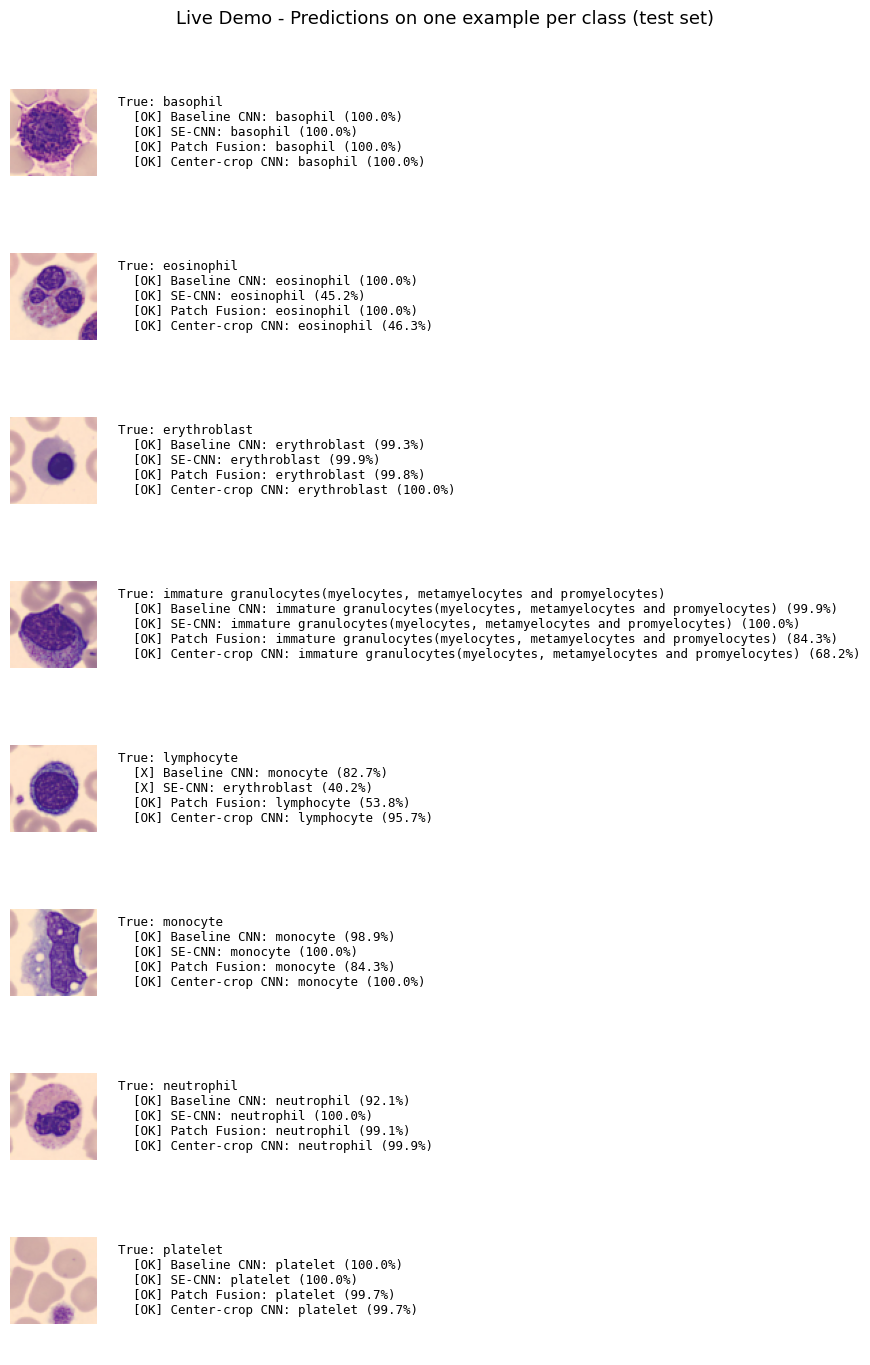


Demo saved to: /kaggle/working/live_demo.png
it shows, live, that the models load and correctly predict on data never seen before.


In [17]:
# 4. Prediction functions 
def predict_simple(model, images):
    """Direct prediction: returns (predicted class, confidence of the predicted class)."""
    probs = model.predict(images, verbose=0)
    preds = np.argmax(probs, axis=1)
    confidences = np.max(probs, axis=1)
    return preds, confidences


def extract_patches(images):
    n = images.shape[0]
    h, w = images.shape[1], images.shape[2]
    half_h, half_w = h // 2, w // 2
    patches = []
    for img in images:
        patches.append(img[0:half_h, 0:half_w, :])
        patches.append(img[0:half_h, half_w:w, :])
        patches.append(img[half_h:h, 0:half_w, :])
        patches.append(img[half_h:h, half_w:w, :])
    return np.stack(patches, axis=0)


def predict_patch_fusion(model, images, n_classes):
    n = images.shape[0]
    patches = extract_patches(images)
    probs = model.predict(patches, verbose=0)
    probs = probs.reshape(n, 4, n_classes)
    avg_probs = probs.mean(axis=1)
    preds = np.argmax(avg_probs, axis=1)
    confidences = np.max(avg_probs, axis=1)
    return preds, confidences


def center_crop(images, crop_size):
    """Same center-crop logic used to train the crop_model: cut out a
    crop_size x crop_size square from the middle of every image."""
    h, w = images.shape[1], images.shape[2]
    start_h = (h - crop_size) // 2
    start_w = (w - crop_size) // 2
    return images[:, start_h:start_h + crop_size, start_w:start_w + crop_size, :]


# 5. Run live predictions on the 8 examples

print("\nRunning predictions...")

pred_baseline, conf_baseline = predict_simple(baseline_model, demo_images_norm)
pred_se, conf_se = predict_simple(se_model, demo_images_norm)
pred_patch, conf_patch = predict_patch_fusion(patch_model, demo_images_norm, n_classes)

CROP_SIZE = 48  # must match the crop size the center_crop_cnn was trained with
demo_images_crop = center_crop(demo_images_norm, CROP_SIZE)
pred_crop, conf_crop = predict_simple(crop_model, demo_images_crop)



# 6. Visualization: one row per example, with image + ground truth + the
#    three predictions (OK if correct, X if wrong)

fig, axes = plt.subplots(n_classes, 1, figsize=(9, n_classes * 1.7))

model_names = ["Baseline CNN", "SE-CNN", "Patch Fusion", "Center-crop CNN"]

for i in range(n_classes):
    ax = axes[i]
    true_label = class_names[demo_labels[i]]

    preds_this_row = [
        (model_names[0], class_names[pred_baseline[i]], conf_baseline[i], pred_baseline[i] == demo_labels[i]),
        (model_names[1], class_names[pred_se[i]], conf_se[i], pred_se[i] == demo_labels[i]),
        (model_names[2], class_names[pred_patch[i]], conf_patch[i], pred_patch[i] == demo_labels[i]),
        (model_names[3], class_names[pred_crop[i]], conf_crop[i], pred_crop[i] == demo_labels[i]),
    ]

    # image on the left
    img_ax = ax.inset_axes([0.0, 0.0, 0.12, 1.0])
    img_ax.imshow(demo_images_raw[i])
    img_ax.axis("off")

    # ground truth + predictions text on the right
    text_lines = [f"True: {true_label}"]
    for name, pred_label, conf, correct in preds_this_row:
        mark = "OK" if correct else "X"
        text_lines.append(f"  [{mark}] {name}: {pred_label} ({conf*100:.1f}%)")

    ax.text(0.15, 0.5, "\n".join(text_lines), fontsize=9, va="center", family="monospace",
            transform=ax.transAxes)
    ax.axis("off")

plt.suptitle("Live Demo - Predictions on one example per class (test set)", y=1.0, fontsize=13)
plt.tight_layout()

demo_output_path = os.path.join(OUTPUT_DIR, "live_demo.png")
plt.savefig(demo_output_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"\nDemo saved to: {demo_output_path}")
print("it shows, live, that the models load and correctly predict on data never seen before.")

In [9]:
import os
for root, dirs, files in os.walk("/kaggle/input/bloodcell-trained-models"):
    for f in files:
        print(os.path.join(root, f))